<h1 style="font-size: 1.6rem; font-weight: bold">ITO5201 Machine Learning</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Perceptron</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Soft Expectation Maximisation for Gaussian Mixture Models**

Given some collection of data $X = \{x_1, ... x_n\}$ and labels with one-to-one correspondance to X, $Z=\{z_1, ... z_n\}$, we can call X the Incomplete Data and $D=(X, Z)$ the Complete Data. We assume that Z is categorical data that can fall into one of K categories. The goal of Expectation Maximisation algorithms is to learn the correspondance between X and Z without having access to Z, and generalise this correspondance to unobserved data. As such, Expectation Maximisation algorithms are a form of unsupervised learning. 

Expectation-Maximisation algorithms follow the following structure:
1. Repeat until convergence or maximum iterations exceeded:
2. Use a surrogate model to compute a guess for the labels $\hat{z_k}$
3. Fit a surrogate model to X and the current best guesses by solving for the Maximum Likelihood Estimates for the model hyperparameters' log likelihood (Refer to Week 7 Slides for more information). 

In this activity, we will be looking at two variants of Gaussian Mixture Models, and our model parameters $\mu$ and $\Sigma$ can be estimated with the following model equations:

\begin{equation}
\mu_k^{(i+1)} = \frac{\sum_{n=1}^N x_n r_{n, k}}{\sum_{i=1}^N r_{n,k}}
\end{equation}

\begin{equation}
\Sigma_k^{(i+1)} = \frac{\sum_{n=1}^N r_{n, k} (x_n - \mu_k^{(i+1)})(x_n - \mu_k^{(i+1)})^T}{\sum_{i=1}^N r_{n,k}}
\end{equation}

And predictions for the probability of each class $r_{n, k}$ can be drawn from it's associated multivariate normal distribution
\begin{equation}
r_{n, k} = \hat{\psi}_k \Phi(X)
\end{equation}
 
\begin{equation}
\Phi(X) \sim N(\hat{\mu}_k, \Sigma_k)
\end{equation} 

\begin{equation}
\hat{\psi}_k =  \frac{\sum_{i=1}^N r_{n, k}}{N}
\end{equation}

(Refer to Week 8 Slides for more information)

Note that SoftEM algorithms predict a probability distribution across all classes. 

In [6]:
import numpy as np
from Activity4 import make_gaussian_mixture_data
import matplotlib.pyplot as plt

def plot_scatter_by_label(X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1)
        fig.set_figheight(6)
        fig.set_figwidth(8)
    categories = np.unique(y)
    for cat in categories:
        ax.scatter(X[y==cat, 0], X[y==cat, 1], label='Cluster {0}'.format(cat), alpha=0.25)
        ax.scatter(np.mean(X[y==cat, 0]), np.mean(X[y==cat, 1]), c='k', marker='x', s=200)
    ax.set_xlabel('X0', size=15)
    ax.set_ylabel('X1', size=15)
    ax.set_title(title if title else "Gaussian Mixture", size=20)
    plt.legend()
    return ax

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32348\2556397343.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Axes: title={'center': 'Non Separable Data'}, xlabel='X0', ylabel='X1'>

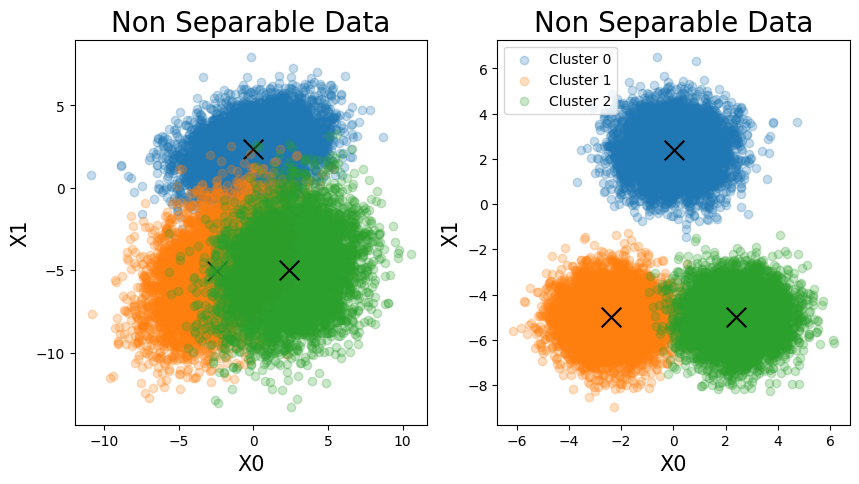

In [7]:
mu0 = 5*np.array([0, np.arctan(np.pi/6)])
mu1 = 5*np.array([np.arctan(-np.pi/6), -1])
mu2 = 5*np.array([np.arctan(np.pi/6), -1])

cov0 = np.array([[5, 1], [1, 2]])
cov1 = np.array([[5, 2], [2, 5]])
cov2 = np.array([[5, 1], [1, 5]])

means = [mu0, mu1, mu2]

covs = [cov0, cov1, cov2]

class_probs = np.array([1, 1, 1])/3

N = 20000
K=3

X_train, y_train = make_gaussian_mixture_data(n=N, means=means, covs=covs, class_probs=class_probs, random_state=0)
X_test, y_test = make_gaussian_mixture_data(n=10000, means=means, covs=covs, class_probs=class_probs, random_state=0)

X_train_sep, y_train_sep = make_gaussian_mixture_data(n=N, means=means, covs=None, class_probs=class_probs, random_state=0)
X_test_sep, y_test_sep = make_gaussian_mixture_data(n=10000, means=means, covs=None, class_probs=class_probs, random_state=0)

fig, axs = plt.subplots(1, 2)
fig.set_figwidth(10)
fig.set_figheight(5)
plot_scatter_by_label(X_train, y_train, ax=axs[0], title='Non Separable Data')
plot_scatter_by_label(X_train_sep, y_train_sep, ax=axs[1], title='Non Separable Data')

### Task B: Implement and predict_proba for SoftEM
Complete the following functions:

The fit function attempts to separate the data into K subgroups, each of which can be fitted to a multivariate normal. This split is iteratively updated with the goal of creating a cleaner split in the data, which can be better fitted to a multivariate normal. 

The predict_proba function maps input data to a probability mass for each of the K classes fitted. 

Note that self.r_historic_ and self.Mu_hat_historic_ are being used to track the intermediate steps of the fitting process. This is not necessary for the algorithm but will be useful later to create some visualisations. 



In [8]:
from scipy.stats import multivariate_normal
class SoftGMM: 
    def __init__(self, K, tau_max=200, epsilon=0.01, random_state=None):
        self.K = K               # number of GMM clusters
        self.tau_max = tau_max   # max number of iterations
        self.epsilon = epsilon  # minimum acceptable error rate
        self.random_state = random_state
        np.random.seed(self.random_state)

    def get_params(self, deep=False):
        return {'K': self.K,
         'tau_max': self.tau_max,
         'epsilon': self.epsilon,
         'random_state': self.random_state}
    
    def __str__(self):
        params = self.get_params()
        return 'SoftGMM({0})'.format(','.join(['='.join([key, str(params[key])]) for key in params.keys()]))

    def __repr__(self):
        return self.__str__()
                
    def fit(self, X, verbose=False):
        N = X.shape[0]
        self.Psi_hat_ = np.array([1/self.K] * self.K)
        self.Nk_hat_ = self.Psi_hat_ * N
        self.Mu_hat_ = X[np.random.choice(N, size=self.K, replace=False)]
        self.Sigma_hat_ = np.array([np.eye(X.shape[1]) for _ in range(self.K)])
        r = np.zeros((N, self.K))

        self.Mu_hat_historic_ = np.zeros(shape=(list(self.Mu_hat_.shape) + [self.tau_max]))
        self.r_historic_ = np.zeros(shape=(N, self.K, self.tau_max))

        terminate = False
        tau = 0
        Mu_hat_old = self.Mu_hat_.copy()   # <-- FIX: .copy() instead of a bare reference
        while (not terminate):
            if verbose: print('iteration {0}'.format(tau))
            # E step
            for k in range(self.K):
                r[:, k] = self.Psi_hat_[k] * multivariate_normal.pdf(
                    X, mean=self.Mu_hat_[k], cov=self.Sigma_hat_[k]
                )
            r = r / r.sum(axis=1, keepdims=True)
            self.r_historic_[:, :, tau] = r

            # M step
            self.Nk_hat_ = r.sum(axis=0)
            self.Psi_hat_ = self.Nk_hat_ / N
            for k in range(self.K):
                self.Mu_hat_[k] = (r[:, k:k+1] * X).sum(axis=0) / self.Nk_hat_[k]
                diff = X - self.Mu_hat_[k]
                self.Sigma_hat_[k] = (r[:, k, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) / self.Nk_hat_[k]

            self.Mu_hat_historic_[:, :, tau] = self.Mu_hat_
            tau += 1

            terminate = ((tau == self.tau_max) or np.allclose(self.Mu_hat_, Mu_hat_old, rtol=self.epsilon))
            Mu_hat_old = self.Mu_hat_.copy()   # <-- FIX: .copy() here too

        self.Mu_hat_historic_ = self.Mu_hat_historic_[:, :, :tau]
        self.r_historic_ = self.r_historic_[:, :, :tau]

        if verbose: print(f'Converged in {tau} iterations')
        return self
        
    def predict_proba(self, x):
        N = x.shape[0]
        r = np.zeros((N,self.K))
        ### YOUR CODE HERE ###
        for k in range(self.K):
            r[:, k] = self.Psi_hat_[k] * multivariate_normal.pdf(
                x, mean=self.Mu_hat_[k], cov=self.Sigma_hat_[k]
            )

        ### END YOUR CODE HERE ###
        r = r/r.sum(axis=1,keepdims=True) # normalization (to make sure sum(r)=1)
        return r

    def predict(self, x):
        probs = self.predict_proba(x)
        preds = np.argmax(probs, axis=1)
        return preds


### Task C: Evaluate the Model

Let's use the self.r_historic_ and self.Mu_hat_historic_ variables to oberve how our model fit evolves during the fitting procedure.

- What do you notice as the number of iterations increases? 
- What differences do you see between the two datasets?

In [9]:
def plot_gmm(gmm, x, gran=3):
    idxs = np.arange(start=0, stop=gmm.r_historic_.shape[-1], step=gran)
    n_plots = len(idxs)
    rows = int(np.sqrt(n_plots))
    cols = int(n_plots//rows) + 1
    fig, axs = plt.subplots(rows, cols)
    fig.set_figheight(5*rows)
    fig.set_figwidth(5*cols)
    for i, idx in enumerate(idxs):
        if not(1 in (rows, cols)):
            j = int(i//cols)
            k = int(i%cols)
            axs[j, k].scatter(x[:,0], x[:,1], c=gmm.r_historic_[:, :, idx], alpha=0.25) # coloring with r will create a mix of RGB colors based on posterior of each point
            axs[j, k].scatter(gmm.Mu_hat_historic_[:,0,idx], gmm.Mu_hat_historic_[:,1,idx], s=200, c='black', marker='x')
            axs[j, k].set_title('EM results (tau={0})'.format(idx))
            axs[j, k].set_xlabel('x1')
            axs[j, k].set_ylabel('x2')
        else:
            axs[i].scatter(x[:,0], x[:,1], c=gmm.r_historic_[:, :, idx], alpha=0.25) # coloring with r will create a mix of RGB colors based on posterior of each point
            axs[i].scatter(gmm.Mu_hat_historic_[:,0,idx], gmm.Mu_hat_historic_[:,1,idx], s=200, c='black', marker='x')
            axs[i].set_title('EM results (tau={0})'.format(idx))
            axs[i].set_xlabel('x1')
            axs[i].set_ylabel('x2')
    return fig, axs

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19
iteration 20
iteration 21
iteration 22
Converged in 23 iterations


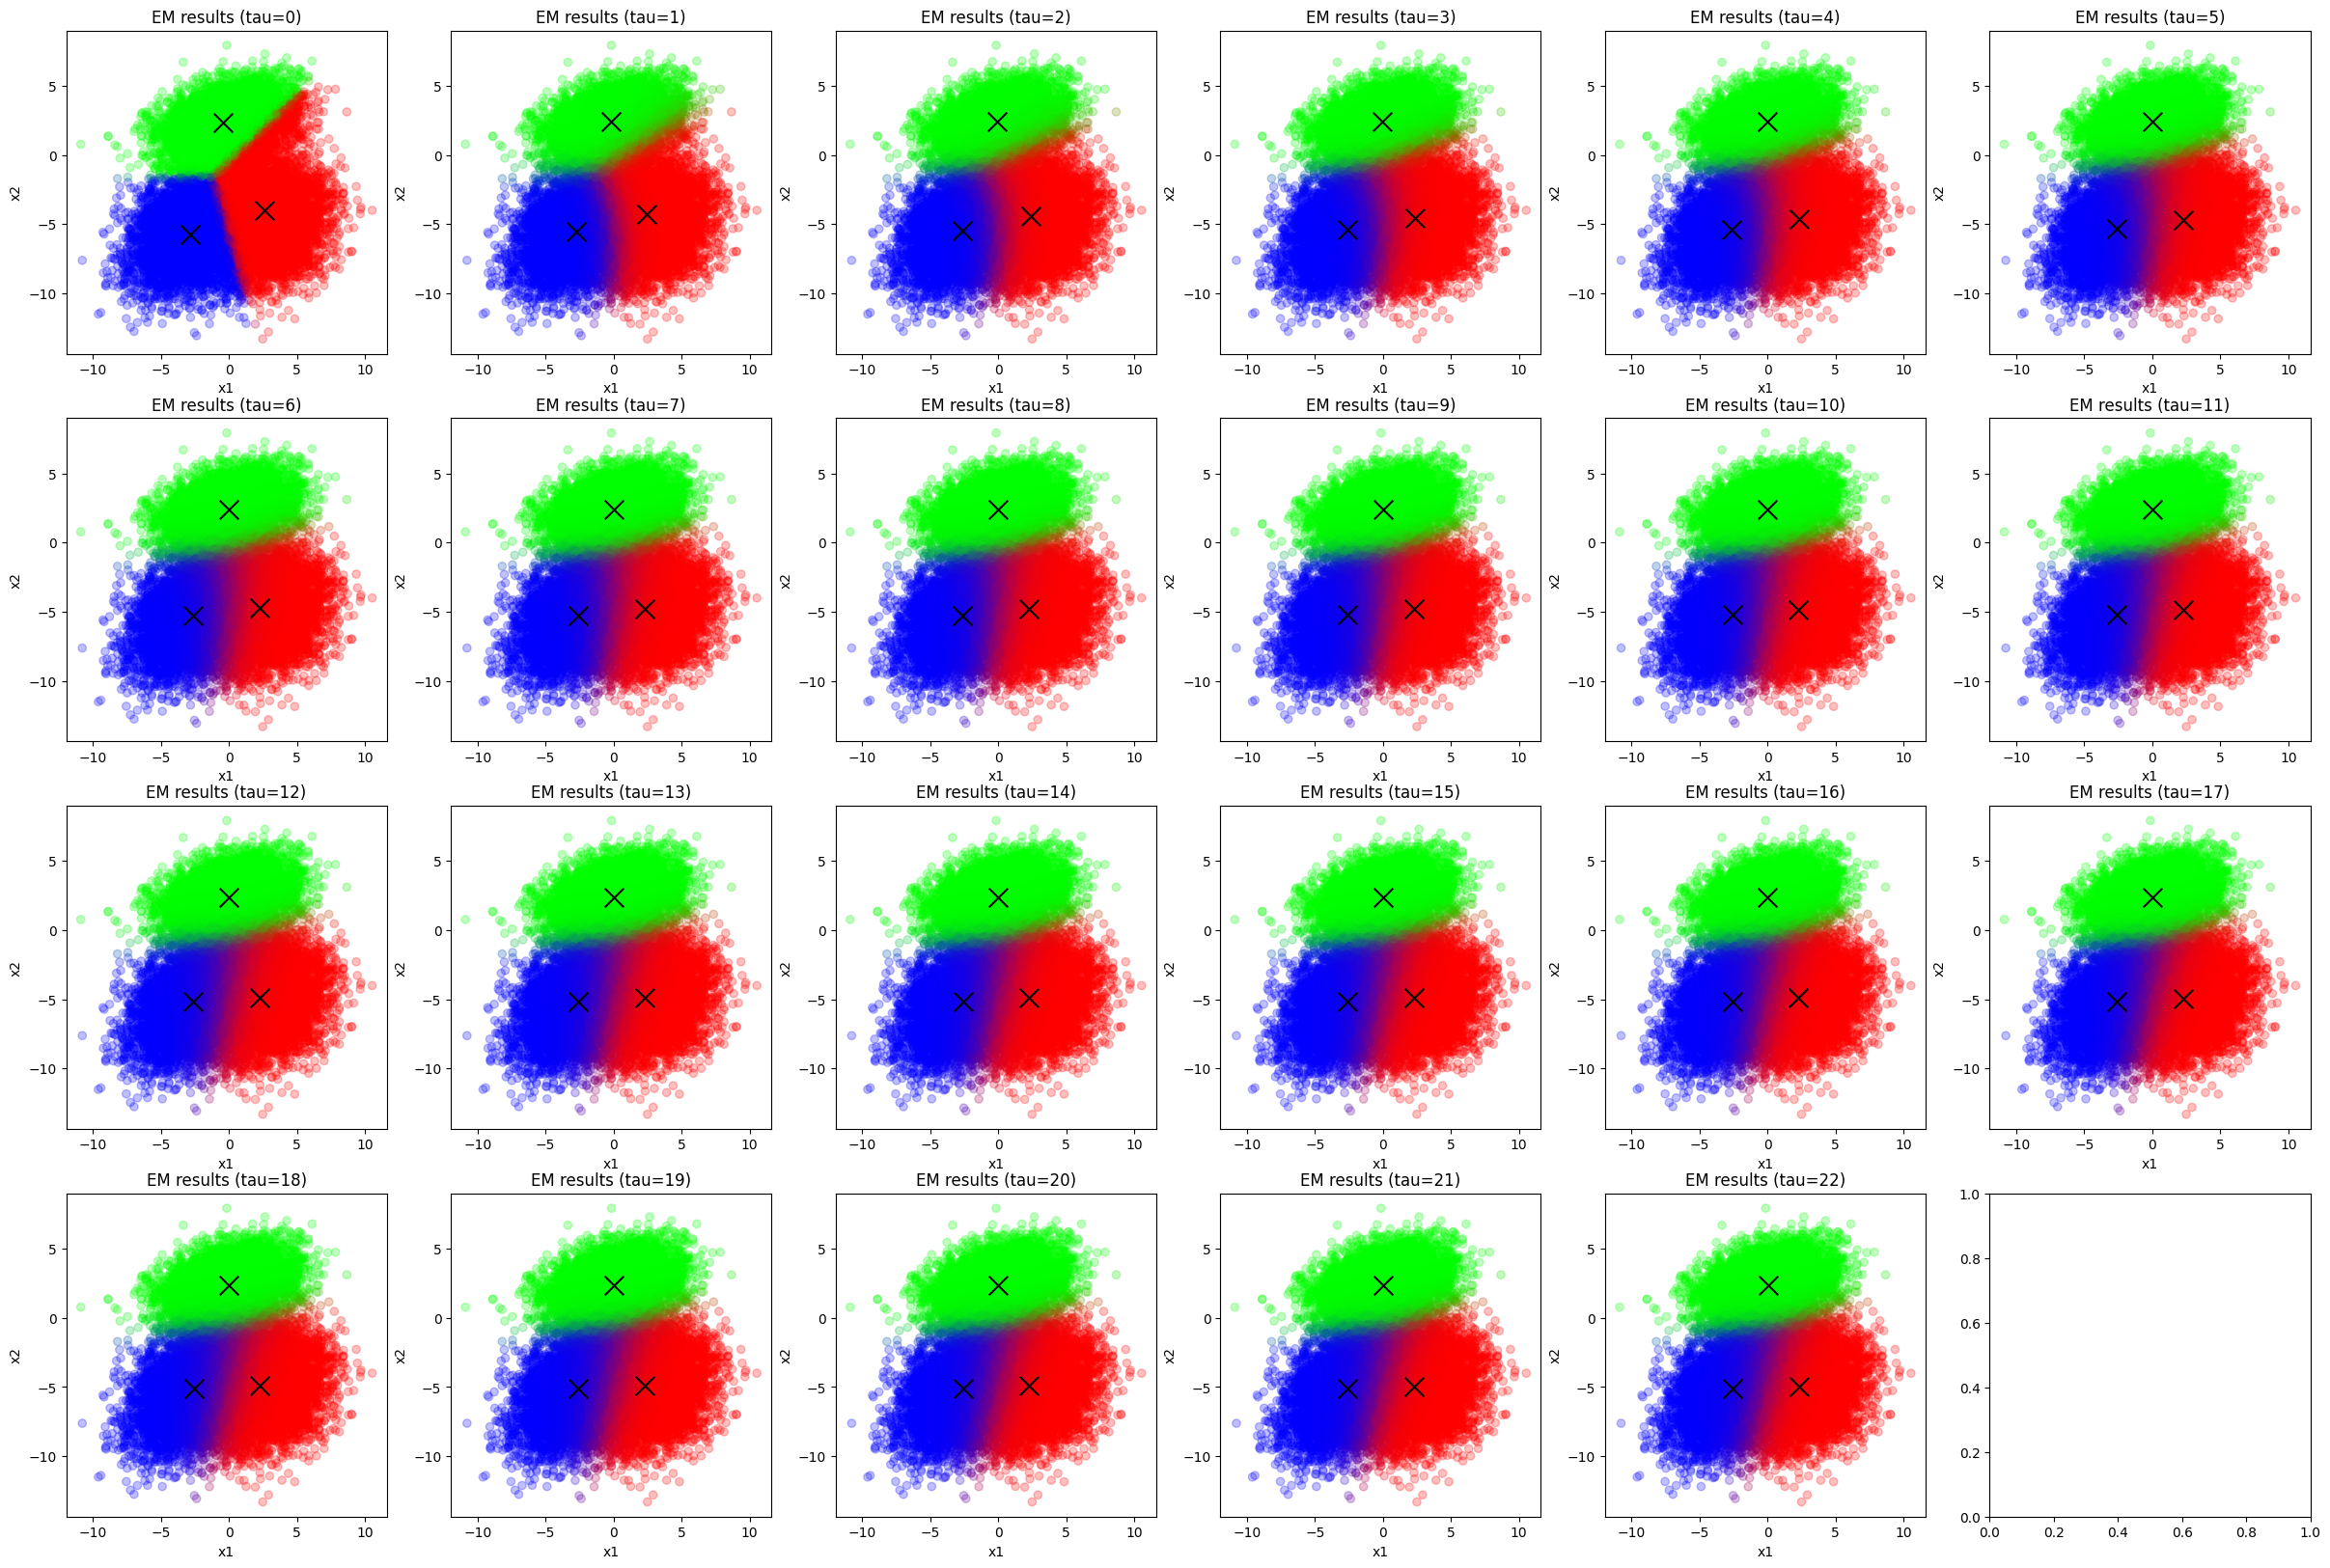

In [10]:
soft_gmm = SoftGMM(K=3, random_state=0)
soft_gmm.fit(X_train, verbose=True)
preds_proba = soft_gmm.predict_proba(X_test)  # soft cluster assignments
preds = soft_gmm.predict(X_test)  # soft cluster assignments
fig, axs = plot_gmm(soft_gmm, X_train, gran=1)
plt.show()

iteration 0
iteration 1
iteration 2
Converged in 3 iterations


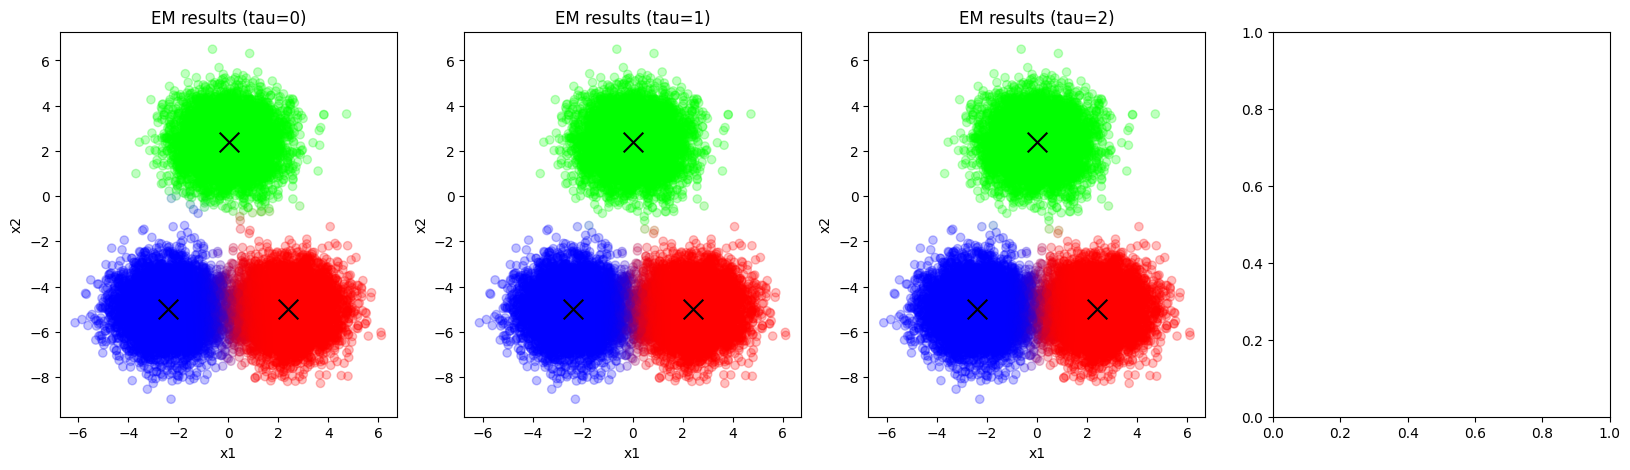

In [11]:
soft_gmm2 = SoftGMM(K=3, random_state=0)
soft_gmm2.fit(X_train_sep, verbose=True)
preds_proba = soft_gmm2.predict_proba(X_test_sep)  # soft cluster assignments
preds = soft_gmm2.predict(X_test_sep)  # soft cluster assignments
fig, axs = plot_gmm(soft_gmm2, X_train_sep, gran=1)
plt.show()

### Task D Plotting True Data against Predictions

We can also use plotting to check how well our model separates the data into the true clusters.

Complete the following function to create a scatter plot of our model's predictions on the various data samples we have. 

Based on the following plots, how well do you think the model generalises to unseen data? Is this plot sufficient evidence to support that claim? If not, what else could we do?

Note: The order of clusters, and hence their means, covariances, etc., may vary as EM has no idea about the real order of the clusters in the generation process. To make it easier to compare these values, you can sort them before comparing them.

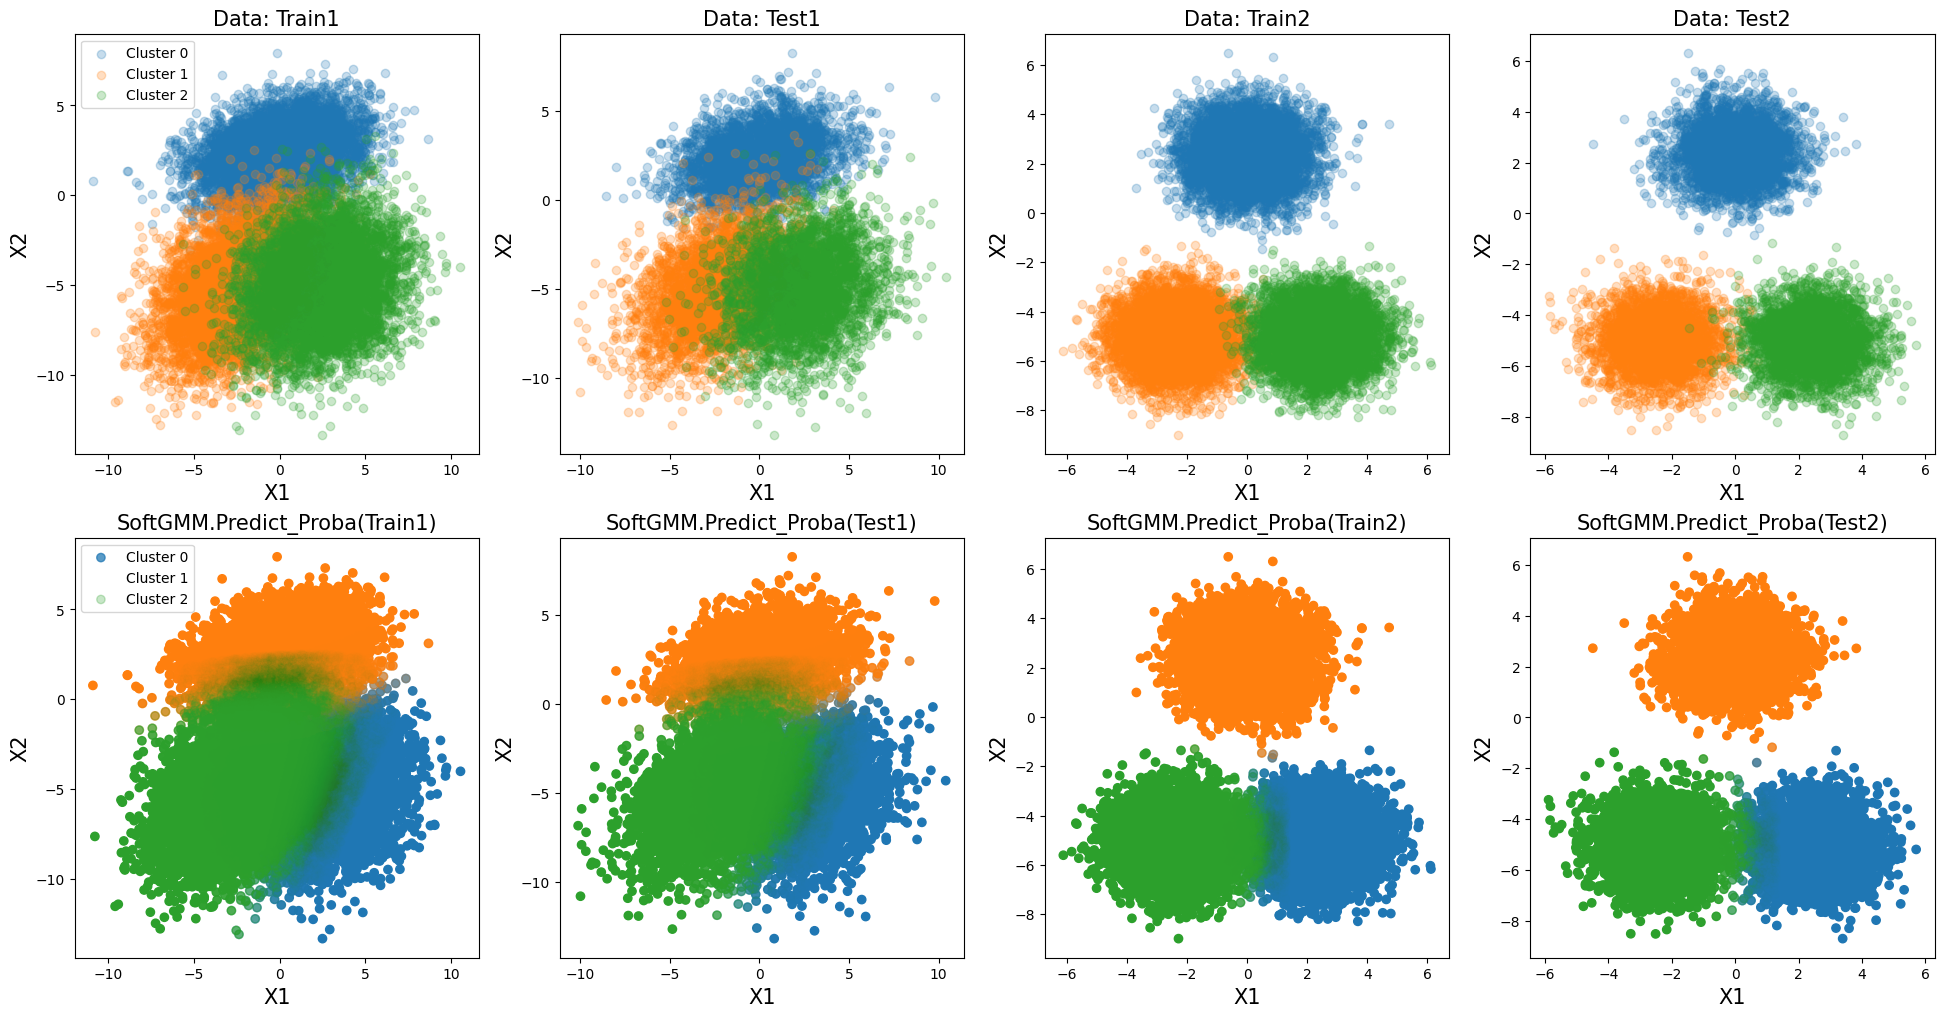

In [12]:
def plot_data_vs_predictions(Xs, ys, names):
    n, m = len(Xs), len(Xs[0])
    fig, axs = plt.subplots(n, m)
    fig.set_figwidth(m*6)
    fig.set_figheight(n*6)
    categories = np.unique(ys[0][0])
    for i in range(n):
        for j in range(m):
            for cat in categories:
                if len(ys[i][j].shape) == 1:  # true labels
                    axs[i, j].scatter(Xs[i][j][ys[i][j]==cat, 0], Xs[i][j][ys[i][j]==cat, 1],
                                       label='Cluster {0}'.format(cat), alpha=0.25)
                else:  # soft predictions
                    probs = ys[i][j][:, cat]
                    axs[i, j].scatter(Xs[i][j][:, 0], Xs[i][j][:, 1], alpha=probs,
                                       label='Cluster {0}'.format(cat))
                axs[i, j].set_xlabel('X1', size=15)
                axs[i, j].set_ylabel('X2', size=15)
                axs[i, j].set_title(names[i][j], size=15)
            axs[i, 0].legend()
    return fig, axs


Xs = [[X_train, X_test, X_train_sep, X_test_sep],
      [X_train, X_test, X_train_sep, X_test_sep]]

ys = [[y_train, y_test, y_train_sep, y_test_sep],
      [soft_gmm.predict_proba(X_train), soft_gmm.predict_proba(X_test),
       soft_gmm2.predict_proba(X_train_sep), soft_gmm2.predict_proba(X_test_sep)]]

names = [['Data: Train1', 'Data: Test1', 'Data: Train2', 'Data: Test2'],
          ['SoftGMM.Predict_Proba(Train1)', 'SoftGMM.Predict_Proba(Test1)',
           'SoftGMM.Predict_Proba(Train2)', 'SoftGMM.Predict_Proba(Test2)']]

fig, axs = plot_data_vs_predictions(Xs, ys, names)
plt.show()

### Hard EM for GMM
In the above experiments, we implemented a SoftEM Gaussian Mixture Model. Now, we modify the code and develop a Hard EM for our GMM. 

In SoftEM we computed a probability distribution across all K classes for each datapoint, whereas in HardEM we simply take the class with the highest probability to be our best guess for the class of a datapoint. 

The vector $\hat{z_n}$ will be used to map our probability density for each class to a vector of all zeros, except at the index corresponding to the class with highest estimated probability, which will have a value of 1. 

\begin{equation}
\hat{z}_{n, k} = 1 \text{ if } k == \argmax(r_n) \text{ else } 0
\end{equation}

*** 

### **Task E: Implement HardGMM**

Complete the fit and predict functions for HardGMM.

Hint: You should be able to reuse a lot of the SoftGMM.fit function but you will need to map your probability vector r to a zero-one vector where the only nonzero element is the most likely class. 

In [ ]:
class HardGMM:
    def __init__(self, K, tau_max=200, epsilon=0.01, random_state=None):
        self.K = K
        self.tau_max = tau_max
        self.epsilon = epsilon
        self.random_state = random_state
        np.random.seed(self.random_state)

    def get_params(self, deep=False):
        return {'K': self.K,
         'tau_max': self.tau_max,
         'epsilon': self.epsilon,
         'random_state': self.random_state}

    def __str__(self):
        params = self.get_params()
        return 'HardGMM({0})'.format(','.join(['='.join([key, str(params[key])]) for key in params.keys()]))

    def __repr__(self):
        return self.__str__()

    def fit(self, X, verbose=False):
        N = X.shape[0]
        self.Psi_hat_ = np.array([1/self.K] * self.K)
        self.Nk_hat_ = self.Psi_hat_ * N
        self.Mu_hat_ = X[np.random.choice(N, size=self.K, replace=False)]
        self.Sigma_hat_ = np.array([np.eye(X.shape[1]) for _ in range(self.K)])
        r = np.zeros((N, self.K))

        self.Mu_hat_historic_ = np.zeros(shape=(list(self.Mu_hat_.shape) + [self.tau_max]))
        self.r_historic_ = np.zeros(shape=(N, self.K, self.tau_max))

        terminate = False
        tau = 0
        Mu_hat_old = self.Mu_hat_.copy()   # .copy() fixes the aliasing bug from SoftGMM too
        while (not terminate):
            if verbose: print('iteration {0}'.format(tau))
            # E step:
            ### YOUR CODE HERE ###
            for k in range(self.K):
                r[:, k] = self.Psi_hat_[k] * multivariate_normal.pdf(
                    X, mean=self.Mu_hat_[k], cov=self.Sigma_hat_[k]
                )
            r = r / r.sum(axis=1, keepdims=True)   # soft posterior first

            # harden: one-hot at the argmax cluster for each point
            z_n_hat = np.zeros_like(r)
            z_n_hat[np.arange(N), np.argmax(r, axis=1)] = 1
            r = z_n_hat   # from here on, r IS the hard assignment used by the M-step below
            ### END YOUR CODE HERE ###
            self.r_historic_[:, :, tau] = z_n_hat

            # M step:
            self.Nk_hat_ = r.sum(axis=0)
            self.Psi_hat_ = self.Nk_hat_ / N
            ### YOUR CODE HERE ###
            for k in range(self.K):
                self.Mu_hat_[k] = (r[:, k:k+1] * X).sum(axis=0) / self.Nk_hat_[k]
                diff = X - self.Mu_hat_[k]
                self.Sigma_hat_[k] = (r[:, k, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) / self.Nk_hat_[k]
            ### END YOUR CODE HERE ###

            self.Mu_hat_historic_[:, :, tau] = self.Mu_hat_
            tau += 1
            terminate = ((tau == self.tau_max) or np.allclose(self.Mu_hat_, Mu_hat_old, rtol=self.epsilon))
            Mu_hat_old = self.Mu_hat_.copy()   # same fix as SoftGMM

        self.Mu_hat_historic_ = self.Mu_hat_historic_[:, :, :tau]
        self.r_historic_ = self.r_historic_[:, :, :tau]

        if verbose: print(f'Converged in {tau} iterations')
        return self

    def predict_proba(self, x):
        N = x.shape[0]
        r = np.zeros((N, self.K))
        ### YOUR CODE HERE ###
        for k in range(self.K):
            r[:, k] = self.Psi_hat_[k] * multivariate_normal.pdf(
                x, mean=self.Mu_hat_[k], cov=self.Sigma_hat_[k]
            )
        ### END YOUR CODE HERE ###
        r = r / r.sum(axis=1, keepdims=True)
        return r

    def predict(self, x):
        probs = self.predict_proba(x)
        preds = np.argmax(probs, axis=1)
        return preds